# 1. Data Preprocessing and Splitting
Load the Obesity dataset (from the given CSV file) and preprocess it. Handle any missing or categorical data using appropriate methods (e.g., Label Encoding, Standard Scaler). Split the dataset into a training set (70%), a validation set (15%), and a test set (15%).

How would you handle categorical variables and scale the data before splitting?*

# 2. Model Training
Train three classifiers: a Random Forest Classifier, an Extra Trees Classifier, and a Support Vector Machine (SVM) classifier on the preprocessed training data.

What are the main hyperparameters you would consider tuning for each classifier to improve their performance?*

# 3. Model Evaluation
Evaluate the performance of the trained models (Random Forest, Extra Trees, and SVM) on the validation set. Report the accuracy scores for each classifier.
Which classifier performed the best on the validation set, and why do you think that is?*

# 4. Ensemble Model
Combine the three classifiers into an Ensemble model using hard voting. Train the ensemble on the training data and evaluate it on the validation set. Does the ensemble model outperform the individual classifiers on the validation set? What are the advantages of using an ensemble model?


In [1]:
import pandas as pd

In [2]:
data = pd.read_csv(r"/Users/zulidobariya/Desktop/6th_sem/ADML/ObesityDataSet.csv")

In [3]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
data.tail()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III


In [5]:
data.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [6]:
data.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [7]:
columns = data.columns
for i in columns:
    print(data[i].unique())

['Female' 'Male']
[21.       23.       27.       ... 22.524036 24.361936 23.664709]
[1.62     1.52     1.8      ... 1.752206 1.73945  1.738836]
[ 64.        56.        77.       ... 133.689352 133.346641 133.472641]
['yes' 'no']
['no' 'yes']
[2.       3.       1.       2.450218 2.880161 2.00876  2.596579 2.591439
 2.392665 1.123939 2.027574 2.658112 2.88626  2.714447 2.750715 1.4925
 2.205439 2.059138 2.310423 2.823179 2.052932 2.596364 2.767731 2.815157
 2.737762 2.568063 2.524428 2.971574 1.0816   1.270448 1.344854 2.959658
 2.725282 2.844607 2.44004  2.432302 2.592247 2.449267 2.929889 2.015258
 1.031149 1.592183 1.21498  1.522001 2.703436 2.362918 2.14084  2.5596
 2.336044 1.813234 2.724285 2.71897  1.133844 1.757466 2.979383 2.204914
 2.927218 2.88853  2.890535 2.530066 2.241606 1.003566 2.652779 2.897899
 2.483979 2.945967 2.478891 2.784464 1.005578 2.938031 2.842102 1.889199
 2.943749 2.33998  1.950742 2.277436 2.371338 2.984425 2.977018 2.663421
 2.753752 2.318355 2.594653 2.88

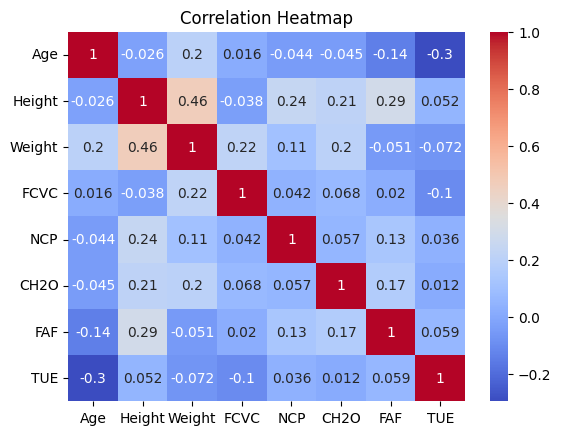

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_columns = data.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = data[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [43]:
numerical_cols = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
categorical_cols = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
target_col = 'NObeyesdad'

In [44]:
from sklearn.preprocessing import LabelEncoder

In [45]:
label_encoders = {}
for column in data.select_dtypes(include='object').columns:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

In [46]:
X = data.drop(columns = 'NObeyesdad')

In [47]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22.0,1.78,89.8,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6


In [48]:
y = data["NObeyesdad"]

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])


In [30]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [40]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [54]:
rf = Pipeline(steps=[('preprocessor', preprocessor),
                     ('classifier', RandomForestClassifier(random_state=42))])
rf.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [58]:
rf_val_pred= rf.predict(X_val)

In [60]:
rf_acc = accuracy_score(y_val, rf_val_pred)
print(f"Random Forest Accuracy: {rf_acc:.2f}")

Random Forest Accuracy: 0.93


In [61]:
et = Pipeline(steps=[('preprocessor',preprocessor),
                     ('classifier',ExtraTreesClassifier(random_state = 42))])
et.fit(X_train,y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('classifier', ExtraTreesClassifier(random_state=42))])

In [63]:
et_val_pred = et.predict(X_val)
et_acc = accuracy_score(y_val,et_val_pred) 

In [64]:
print(f"ExtraTree Accuracy: {et_acc:.2f}")

ExtraTree Accuracy: 0.91


In [65]:
sv = Pipeline(steps = [('preprocessor',preprocessor),
                       ('classifier',SVC(random_state=42))])

In [66]:
sv.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'family_history_with_overweight',
                                                   'FAVC', 'CAEC', 'SMOKE',
                                                   'SCC', 'CALC',
                                                   'MTRANS'])])),
                ('classifier', SVC(random_state=42))])

In [67]:
sv_val_pred = sv.predict(X_val)

In [68]:
sv_acc = accuracy_score(y_val,sv_val_pred)

In [69]:
print(f"SVM Accuracy: {sv_acc:.2f}")

SVM Accuracy: 0.91


In [70]:
ensemble = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(random_state=42)),
    ('et', ExtraTreesClassifier(random_state=42)),
    ('sv', SVC(random_state=42))
], voting='hard')

ensemble.fit(preprocessor.fit_transform(X_train), y_train)
ensemble_val_pred = ensemble.predict(preprocessor.transform(X_val))
ensemble_acc = accuracy_score(y_val, ensemble_val_pred)

In [72]:
print(f"Ensemble Accuracy: {ensemble_acc:.2f}")

Ensemble Accuracy: 0.92


# 5. Hyperparameter tuning
perform Grid Search to tune the hyperparameters of the SVM classifier to get the best performance.After tuning,train  the best SVM model again and evaluate it on the test set. How much does tuning the SVM hyperparameters improve the model performance on the test set?

# 6. Ensemble with Tuning
After tuning the SVM model,integrate the tuned SVM into the ensemble model.Evaluate this enhanced ensemble model on the test set.How does performance of the ansemble with the tuned SVM compare to the previous ensemble model?

# 7. Model Performance Comparison
Compare the final test accuracies of the best SVM, Random Forest, Extra Trees, and the Ensemble model (hard voting). Which model performed the best on the test set, and why?

# 8. Inference & Conclusion
Based on the results of the above models, summarize the key findings. What insights can you infer about the relationship between the features (e.g., age, height, weight) and obesity risk? What conclusions can you draw about the importance of each feature in predicting obesity risk, and which model would you recommend for future use?

# 9. Model Deployment
How would you deploy the final best-performing model (e.g., the ensemble model) into a production environment for real-time predictions? What steps would you follow for deployment, including packaging, testing, and serving the model? What tools and technologies would you use to deploy the model and monitor its performance in production?

# 10. Inference and Real-World Impact
How would you interpret the results from your final model in a real-world scenario? How could the model help healthcare providers or policymakers in addressing obesity and its risks? What ethical considerations and potential challenges would you face when deploying the model in the healthcare domain?


In [74]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': [1, 0.1, 0.01, 0.001],
    'classifier__kernel': ['rbf', 'linear']
}
svm_grid = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', SVC(random_state=42))])

grid_search = GridSearchCV(svm_grid, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_

svm_test_pred = best_svm.predict(X_test)
svm_test_acc = accuracy_score(y_test, svm_test_pred)



In [75]:
ensemble = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(random_state=42)),
    ('et', ExtraTreesClassifier(random_state=42)),
    ('svm', best_svm.named_steps['classifier'])
], voting='hard')

ensemble.fit(preprocessor.fit_transform(X_train), y_train)
ensemble_test_pred = ensemble.predict(preprocessor.transform(X_test))
ensemble_test_acc = accuracy_score(y_test, ensemble_test_pred)

rf_test_pred = rf.predict(X_test)
et_test_pred = et.predict(X_test)
rf_test_acc = accuracy_score(y_test, rf_test_pred)
et_test_acc = accuracy_score(y_test, et_test_pred)


In [78]:
print(f"Random Forest Test Accuracy: {rf_test_acc:.2f}")
print(f"Extra Trees Test Accuracy: {et_test_acc:.2f}")
print(f"Tuned SVM Test Accuracy: {svm_test_acc:.2f}")
print(f"Enhanced Ensemble Test Accuracy: {ensemble_test_acc:.2f}")

Random Forest Test Accuracy: 0.92
Extra Trees Test Accuracy: 0.89
Tuned SVM Test Accuracy: 0.94
Enhanced Ensemble Test Accuracy: 0.92
